In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Carregar as 3 tabelas tratadas
customers = pd.read_csv('customers.csv')
products  = pd.read_csv('products.csv')
reviews   = pd.read_csv('reviews.csv')

# Juntar tudo em um único dataframe para a EDA
df = reviews.merge(customers, on='customer_id', how='left') \
            .merge(products, on='product_id', how='left')

# Garantir que a data está no formato certo
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

print(df.shape)
df.head()

(14229, 15)


,review_date,customer_id,product_id,rating,recommend_to_friend,review_title,review_text,sentiment,birth_year,gender,state,product_name,brand,category_lvl1,category_lvl2
0,2018-01-01 06:05:50,33bba21e9131130728f945c135f08f0aafcb5abb422ee5...,11466760,5,Yes,incrível!,"Máscara de cílios incrível, tenho pouquíssimo ...",Positive,1989.0,F,RJ,Grandiôse Lancôme - Máscara Para Os Cílios 01,NaN,Beleza e Perfumaria,Maquiagem
1,2018-01-01 06:09:58,c64fba6b296db674d690787594b8c50dfb46d5a30e7159...,130788449,4,Yes,Eficiente,"Cabelos alinhados, sem frizz e muito mais rápi...",Positive,1976.0,F,SP,Escova Soft Brush 1000W - Philco,philco,Beleza e Perfumaria,Aparelhos elétricos para cabelo
2,2018-01-01 06:09:58,c64fba6b296db674d690787594b8c50dfb46d5a30e7159...,130788449,4,Yes,Eficiente,"Cabelos alinhados, sem frizz e muito mais rápi...",Positive,1976.0,F,SP,Escova Soft Brush 1000W - Philco,philco,Beleza e Perfumaria,Aparelhos elétricos para cabelo
3,2018-01-01 06:51:09,5be7d2822debc9fa857b033df66a66d8aee7e9fdf19d69...,18442566,5,Yes,excelente,"Excelente produto, esquenta, dá o formato dese...",Positive,1958.0,F,RJ,Modelador de Cachos - Preto,NaN,Beleza e Perfumaria,Cabelo
4,2018-01-01 07:33:34,8da4c516a83914b17c158671f6acb7cd4763f8a76494fa...,132540181,5,Yes,Barbeador.,Aparelho de excelente qualidade. Faz o que pro...,Positive,1956.0,M,SP,Oneblade QP2530/20 com 4 Pentes - Philips,NaN,Beleza e Perfumaria,Barbearia


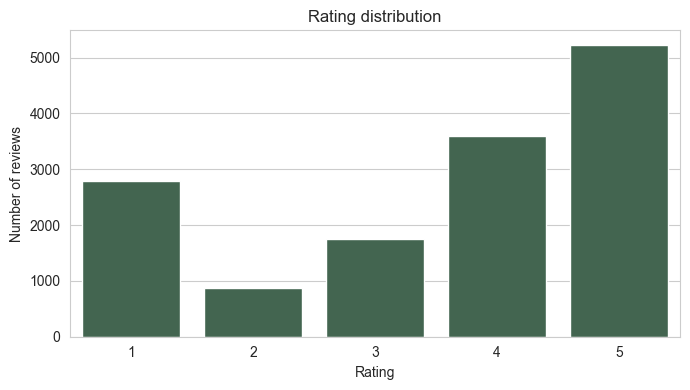

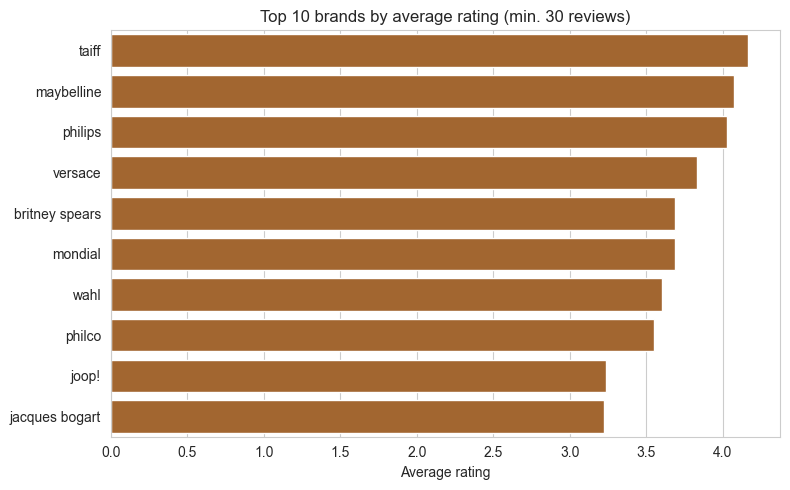

              avg_rating  recommend_rate
gender                                  
F                   3.54           74.56
M                   3.51           74.41
NOT INFORMED        3.62           70.86


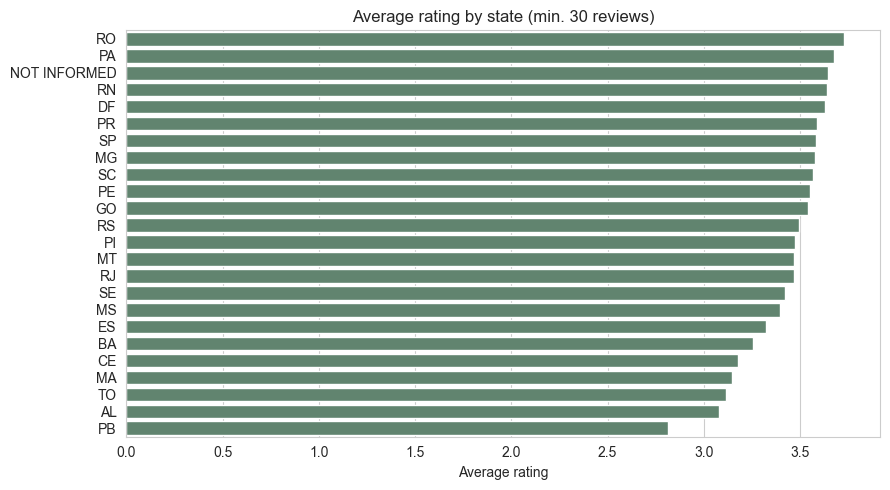

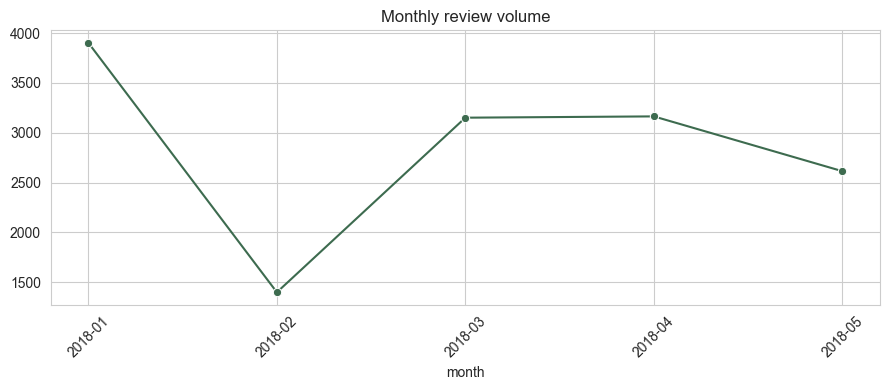


KEY INSIGHTS:
1. ...
2. ...
3. ...



In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
PALETTE = ['#3D6B4F', '#B5651D', '#5B8A6E', '#8C8C8C']

# --- Distribuição das notas ---
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='rating', color=PALETTE[0])
plt.title('Rating distribution')
plt.xlabel('Rating'); plt.ylabel('Number of reviews')
plt.tight_layout(); plt.savefig('chart_01_rating_distribution.png'); plt.show()


# --- Nota média por marca (top 10) ---
top_brands = (
    df.groupby('brand')['rating']
    .agg(['mean', 'count'])
    .query('count >= 30')
    .sort_values('mean', ascending=False)
    .head(10)
)
plt.figure(figsize=(8,5))
sns.barplot(x=top_brands['mean'], y=top_brands.index, color=PALETTE[1])
plt.title('Top 10 brands by average rating (min. 30 reviews)')
plt.xlabel('Average rating'); plt.ylabel('')
plt.tight_layout(); plt.savefig('chart_02_top_brands.png'); plt.show()

# --- Nota e recomendação por gênero ---
by_gender = df.groupby('gender').agg(
    avg_rating=('rating', 'mean'),
    recommend_rate=('recommend_to_friend', lambda x: (x == 'Yes').mean() * 100)
).round(2)
print(by_gender)

# --- Nota média por estado ---
by_state = (
    df.groupby('state')['rating']
    .agg(['mean', 'count'])
    .query('count >= 30')
    .sort_values('mean', ascending=False)
)
plt.figure(figsize=(9,5))
sns.barplot(x=by_state['mean'], y=by_state.index, color=PALETTE[2])
plt.title('Average rating by state (min. 30 reviews)')
plt.xlabel('Average rating'); plt.ylabel('')
plt.tight_layout(); plt.savefig('chart_03_rating_by_state.png'); plt.show()

# --- Evolução mensal do volume de avaliações ---
df['month'] = df['review_date'].dt.to_period('M')
trend = df.groupby('month').size()
plt.figure(figsize=(9,4))
sns.lineplot(x=trend.index.astype(str), y=trend.values, color=PALETTE[0], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly review volume')
plt.tight_layout(); plt.savefig('chart_04_monthly_trend.png'); plt.show()

# --- Resumo de insights ---
insights = '''
KEY INSIGHTS:
1. ...
2. ...
3. ...
'''
print(insights)